# Set Up

In [1]:
!pip install htrc-feature-reader
!pip install stopwordsiso
!pip install fasttext

In [2]:
import requests
import json 
import pandas as pd
import string
from collections import Counter
from htrc_features import Volume
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import stopwordsiso as stopwords
from htrc_features import Volume

# Import Workset

In [9]:
workset_1 = requests.get("https://worksets.hathitrust.org/wsid/3b7d1e60-323f-11f1-806f-2d821d8659ab")

workset_content_1 = workset_1.content
data_1 = json.loads(workset_content_1)

data_1 = data_1['gathers']

readable_json_1 = json.dumps(data_1, indent=4) # Indent with 4 spaces

In [10]:
x_1 = readable_json_1.split()
y = "http://hdl.handle.net/2027/"
volumes_1 = []
for i in x_1:
    if y in i:
        z_1 = i.replace(y,"")
        z_1 = z_1.replace('"',"")
        volumes_1.append(z_1)

In [8]:
counter_1 = Counter()
for i in volumes_1:
    try: 
        vol_1 = Volume(i, download=True)
        for page in vol_1.pages():
            for word in page.tokens():
                counter_1.update(page.tokens())
    except Exception as e:
        continue

ERROR:root:HTTP Error accessing http://data.analytics.hathitrust.org/features-2020.03/hvd/hw/hvd.hxnwyv.json.bz2
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/caching.py", line 73, in open
    fout = super().open(id, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 121, in open
    uncompressed = self._open(id = id, suffix = suffix, mode = mode, format = format,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 203, in _open
    return Path(dir, filename).open(mode = mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/pathlib.py", line 1013, in open
    return io.open(self, mode, buffering, encoding, errors, newline)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Fil

In [19]:
workset_2 = requests.get("https://worksets.hathitrust.org/wsid/3b7d1e60-323f-11f1-806f-2d821d8659ab")

workset_content_2 = workset_2.content
data_2 = json.loads(workset_content_2)

data_2 = data_2['gathers']

readable_json_2 = json.dumps(data_2, indent=4) # Indent with 4 spaces

In [20]:
x_2 = readable_json_2.split()
volumes_2 = []
for i in x_2:
    if y in i:
        z_2 = i.replace(y,"")
        z_2 = z_2.replace('"',"")
        volumes_2.append(z_2)

In [21]:
counter_2 = Counter()
for i in volumes_2:
    try: 
        vol_2 = Volume(i, download=True)
        for page in vol_2.pages():
            for word in page.tokens():
                counter_2.update(page.tokens())
    except Exception as e:
        continue

ERROR:root:HTTP Error accessing http://data.analytics.hathitrust.org/features-2020.03/hvd/hw/hvd.hxnwyv.json.bz2
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/caching.py", line 73, in open
    fout = super().open(id, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 121, in open
    uncompressed = self._open(id = id, suffix = suffix, mode = mode, format = format,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 203, in _open
    return Path(dir, filename).open(mode = mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/pathlib.py", line 1013, in open
    return io.open(self, mode, buffering, encoding, errors, newline)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Fil

# Stopwords

In [22]:
stop = ['af','ar', 'hy','eu','bn','br','bg','ca','cs','zh','da','de','nl','el','en','eo','et','fa','fi','fr','ga','gl','gu','ha','he','hi','hr','hu','id','it','ja','ko','ku','la','lv','lt','mr','ms','no','pl','pt','ro','ru','sk','sl','so','st','es','sw','sv','tl','th','tr','uk','ur','vi','yo','zu']
hathi =['afr', 'ara', 'arm', 'baq', 'ben', 'bre', 'bul', 'cat', 'cze','chi','dan','ger','dut','gre','eng','-esp','est','per','fin','fre','-iri','-gag','guj','hau','heb','hin','hrv', 'hun','ind','ita','jpn','kor','kur','lat','lav','lit','mar','may','nor','pol','por','rum','rus','slo','slv','som','-sso','spa','swa','swe','tgl','tha','tur','ukr','urd','vie','yor','zul']

In [23]:
vol_test_1 = Volume(volumes_1[0])
workset_1_lan = vol_test_1.language
index = hathi.index(workset_1_lan)
stopword_lan_1 = stop[index]
stopwords_1 = stopwords.stopwords(stopword_lan_1)

In [26]:
vol_test_2 = Volume(volumes_2[0])
workset_2_lan = vol_test_2.language
index = hathi.index(workset_2_lan)
stopword_lan_2 = stop[index]
stopwords_2 = stopwords.stopwords(stopword_lan_2)

# Clean Data

In [27]:
df_workset_1 = pd.DataFrame({'count': counter_1})
df_workset_1 = df_workset_1.reset_index()
df_workset_1 = df_workset_1.rename(columns={'index': 'word'})
df_workset_1 = df_workset_1.sort_values(by='count', ascending=False)
df_workset_1 = df_workset_1[~df_workset_1['word'].isin(stopwords_1)]
df_workset_1 = df_workset_1[~df_workset_1['word'].isin(stop.title() for stop in stopwords_1)]
df_workset_1 = df_workset_1[~df_workset_1['word'].isin(list(string.punctuation))]

In [28]:
df_workset_2 = pd.DataFrame({'count': counter_1})
df_workset_2 = df_workset_2.reset_index()
df_workset_2 = df_workset_2.rename(columns={'index': 'word'})
df_workset_2 = df_workset_2.sort_values(by='count', ascending=False)
df_workset_2 = df_workset_2[~df_workset_2['word'].isin(stopwords_2)]
df_workset_2 = df_workset_2[~df_workset_2['word'].isin(stop.title() for stop in stopwords_2)]
df_workset_2 = df_workset_2[~df_workset_2['word'].isin(list(string.punctuation))]

# Translation

# Word Cloud

In [29]:
cloud_1 = ' '.join(df_workset_1['word'].astype(str).tolist())

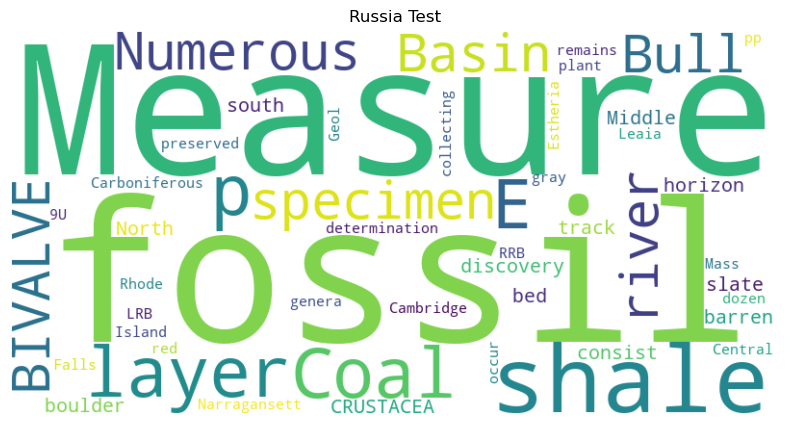

In [30]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(cloud_1)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Russia Test")
plt.show()

In [31]:
cloud_2 = ' '.join(df_workset_2['word'].astype(str).tolist())

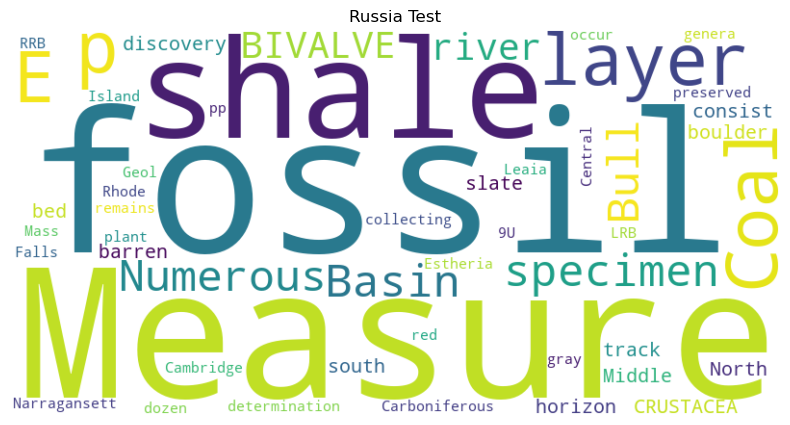

In [32]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(cloud_2)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Russia Test")
plt.show()

# Frequency to Frequency Graph

In [39]:
df_compare = pd.merge (df_workset_1.head(50), df_workset_2.head(50), how ='outer', left_on='word', right_on='word')
df_compare = df_compare.fillna(0)
df_compare = df_compare.rename(columns={"count_x":"count_workset_1", "count_y":"count_workset_2"})
df_compare['count_workset_1'] += 1
df_compare['count_workset_2'] += 1
df_compare['ratio'] = np.log2(df_compare['count_workset_1'] / df_compare['count_workset_2'])
df_compare

,word,count_workset_1,count_workset_2,ratio
0,-80,324,324,0.0
1,-LRB-,520,520,0.0
2,-LSB-,324,324,0.0
3,-RRB-,520,520,0.0
4,454,324,324,0.0
5,9U,324,324,0.0
6,Acad,324,324,0.0
7,BIVALVE,324,324,0.0
8,Basin,520,520,0.0
9,Brown,324,324,0.0


In [ ]:
fig = px.scatter(
    df_compare, 
    x="count_workset_2", 
    y="count_workset_1",
    text="word",
    color="ratio",
    log_x=True, 
    log_y=True,
    color_continuous_scale='RdBu_r', 
    color_continuous_midpoint=0,     
    labels={
        "count_rus": "Occurrences in Workset 2 Texts",
        "count_en": "Occurrences in Workset 1 Texts"
    },
    title="Stop Words in English and Russian Texts"
)

# Styling to match the screenshot
fig.update_traces(textposition='top center')
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey'),
)

fig.show()